Вес (w₁): 2.4080
Смещение (b): 0.4302
MAE: 1.4021
RMSE: 1.7962
R²: 0.9403


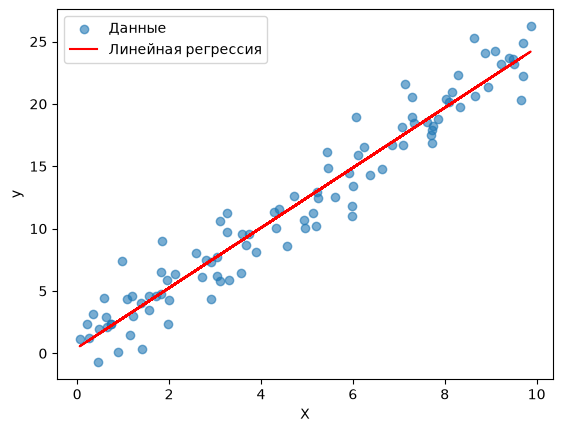

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)

# Генерируем данные
X = np.random.uniform(0, 10, 100).reshape(-1, 1)
y = 2.5 * X.flatten() + np.random.normal(0, 2, 100)

# Обучаем модель
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

# Метрики
mae = mean_absolute_error(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y, y_pred)

print(f"Вес (w₁): {model.coef_[0]:.4f}")
print(f"Смещение (b): {model.intercept_:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

# Визуализация
plt.scatter(X, y, alpha=0.6, label='Данные')
plt.plot(X, y_pred, color='red', label='Линейная регрессия')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

In [44]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error


class myLinearRegression:
    def fit(self,x,y):
        X = np.c_[np.ones((x.shape[0],1)),x]
        
        self.w = np.linalg.inv(X.T @ X)@X.T@y
    
    def predict(self,x):
        X = np.c_[np.ones((x.shape[0],1)),x]

        return X @ self.w

In [45]:
X = np.linspace(-5,5,40).reshape(-1,1)

In [46]:
np.random.seed(42)
X = np.linspace(-5,5,40).reshape(-1,1)
y = 2 * X.flatten() + 5 + np.random.normal(0,1,40)
y

array([-4.50328585, -4.62544379, -3.32667044, -1.93850861, -3.18287132,
       -2.67003439, -0.34386411, -0.64282168, -1.36691028,  0.15794466,
       -0.33521256,  0.17529589,  1.39580843, -0.24661358,  0.45456935,
        2.13002016,  2.19229708,  4.03219605,  3.32274516,  3.33128604,
        6.72205903,  5.54345447,  6.34957949,  5.37012361,  6.76330958,
        7.93143541,  7.18233976,  9.22185186,  8.75833567,  9.58010112,
        9.78290877, 12.74971408, 11.39675919, 10.86536599, 13.25844235,
       11.7278743 , 13.67040206, 12.01468885, 13.15899344, 15.19686124])

In [52]:
model_with_bias = myLinearRegression()
model_with_bias.fit(X,y)
y_pred_with_bias = model_with_bias.predict(X)

In [48]:
# Обучаем класс без intercept (для сравнения)
class LinearRegressionOLS_NoBias:
    def fit(self, X, y):
        # БЕЗ столбца единиц!
        self.weights = np.linalg.inv(X.T @ X) @ X.T @ y

    def predict(self, X):
        return X @ self.weights

In [51]:
model_no_bias = LinearRegressionOLS_NoBias()
model_no_bias.fit(X, y)
y_pred_no_bias = model_no_bias.predict(X)

# Сравниваем веса
print("С intercept:")
print(f"  weights: {model_with_bias.w}")
print(f"  intercept (w0): {model_with_bias.w[0]:.4f}")
print(f"  slope (w1): {model_with_bias.w[1]:.4f}")
print()
print("Без intercept:")
print(f"  weights: {model_no_bias.weights}")
print(f"  slope (w0): {model_no_bias.weights[0]:.4f}")


С intercept:
  weights: [4.78136316 1.92039338]
  intercept (w0): 4.7814
  slope (w1): 1.9204

Без intercept:
  weights: [1.92039338]
  slope (w0): 1.9204


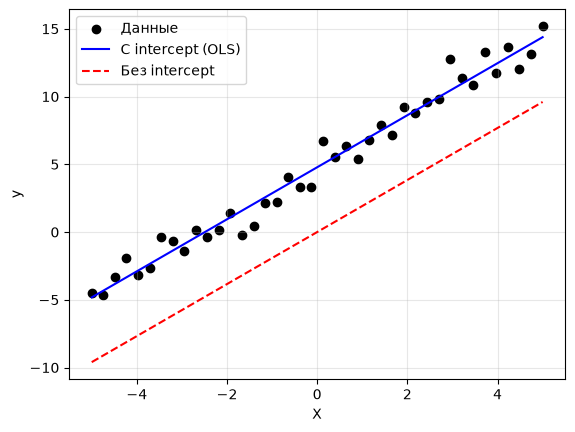

In [ ]:
# Визуализация
plt.scatter(X, y, color='black', label='Данные')
plt.plot(X, y_pred_with_bias, color='blue', label='С intercept (OLS)')
plt.plot(X, y_pred_no_bias, color='red', linestyle='--', label='Без intercept')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [54]:
# Генерируем данные
np.random.seed(42)
X = np.random.uniform(0, 10, 100).reshape(-1, 1)
y = 2.5 * X.flatten() + 5 + np.random.normal(0, 2, 100)

In [ ]:
X_b = np.c_[np.ones((X.shape[0], 1)), X]

In [59]:
# Параметры
learning_rate = 0.01
n_iterations = 1000
n = len(y)

w = np.random.randn(2)
loss_hist = []
w

array([-0.26465683,  2.72016917])

In [63]:
for i in range(n_iterations):
    y_pred = X_b @ w
    loss = np.mean((y-y_pred)**2)
    loss_hist.append(loss)
    # print(loss)
    grad = -2/n * X_b.T @ (y-y_pred)

    w -= learning_rate * grad

print(f"Итоговые веса: {w}")
print(f"Истинные веса: [5.0, 2.5]")

Итоговые веса: [5.43010958 2.40805807]
Истинные веса: [5.0, 2.5]


In [ ]:
import random
X = random.shuffle(X)


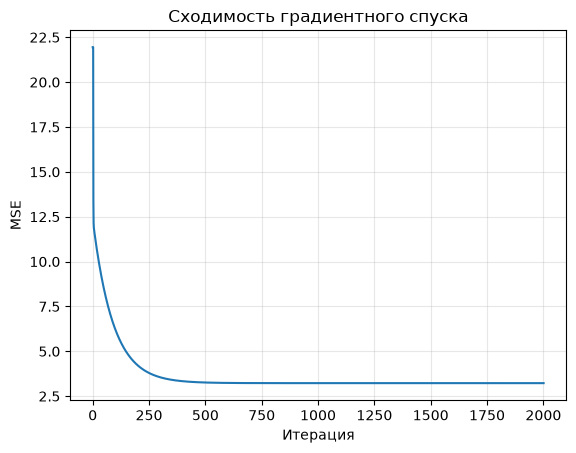

In [64]:
plt.plot(loss_hist)
plt.xlabel('Итерация')
plt.ylabel('MSE')
plt.title('Сходимость градиентного спуска')
plt.grid(True, alpha=0.3)
plt.show()

In [101]:
class LinearRegressionGD:
    def __init__(self,learning_rate=0.01,n_epochs=50,batch_size=32):
        self.learning_rate = learning_rate
        self.n_epochs = n_epochs
        self.batch_size = batch_size
    
    def fit(self,X,y):
        X = np.c_[np.ones((X.shape[0],1)),X]
        self.w = np.random.randn(X.shape[1])
        
        i = 0
        n=len(y)
        self.loss_hist = []
        for _ in range(self.n_epochs):
            indices = np.random.permutation(n)
            X_shuffled = X[indices]
            y_shuffled = y[indices]
            
            for i in range(0,n,self.batch_size):
                X_batch = X_shuffled[i:i+self.batch_size]
                y_batch = y_shuffled[i:i+self.batch_size]
                y_pred_batch = X_batch @ self.w
                grad = (2/self.batch_size) * X_batch.T @ (y_pred_batch-y_batch)
                self.w -= self.learning_rate * grad
            self.loss_hist.append(np.mean((X_shuffled@self.w-y_shuffled)**2))

    def predict(self,X):
        X = np.c_[np.ones((X.shape[0],1)),X]
        return X@self.w


In [102]:
# Генерируем данные
np.random.seed(42)
X = np.random.uniform(0, 10, 100).reshape(-1, 1)
y = 3 * X.flatten() + 2 + np.random.normal(0, 2, 100)

In [103]:
model = LinearRegressionGD()
model.fit(X,y)
y_pred = model.predict(X)

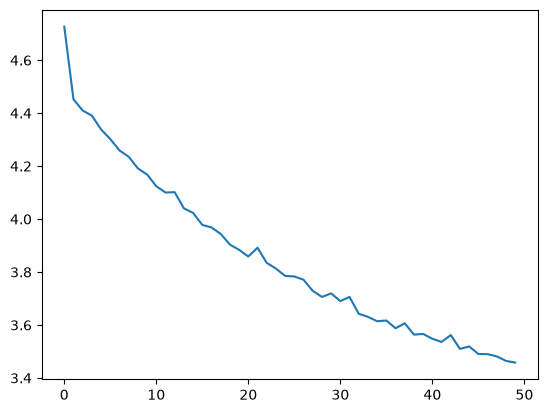

In [104]:
plt.plot(model.loss_hist)

In [95]:
np.random.seed(42)
X = np.random.uniform(0, 10, 100).reshape(-1, 1)
y = 2.5 * X.flatten() + 5 + np.random.normal(0, 2, 100)

model = LinearRegressionGD(learning_rate=0.01, n_epochs=100, batch_size=32)
model.fit(X, y)

print(f"Веса: {model.w}")  # должно быть около [5, 2.5]
print(f"Последний loss: {model.loss_hist[-1]:.4f}")

Веса: [4.52482889 2.53667252]
Последний loss: 3.4616


In [105]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = model.predict(X)

mae = mean_absolute_error(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y, y_pred)

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

MAE: 1.4956
MSE: 3.4582
RMSE: 1.8596
R²: 0.9553


In [ ]:
class LinearRegressionGD:
    def __init__(self,learning_rate=0.01,n_epochs=50,batch_size=32):
        self.learning_rate = learning_rate
        self.n_epochs = n_epochs
        self.batch_size = batch_size
    
    def fit(self,X,y):
        X = np.c_[np.ones((X.shape[0],1)),X]
        self.w = np.random.randn(X.shape[1])
        
        n=len(y)
        self.loss_hist = []
        for _ in range(self.n_epochs):
            indices = np.random.permutation(n)
            X_shuffled = X[indices]
            y_shuffled = y[indices]
            
            for i in range(0,n,self.batch_size):
                X_batch = X_shuffled[i:i+self.batch_size]
                y_batch = y_shuffled[i:i+self.batch_size]
                y_pred_batch = X_batch @ self.w
                grad = (2/self.batch_size) * X_batch.T @ (y_pred_batch-y_batch)
                self.w -= self.learning_rate * grad
            self.loss_hist.append(np.mean((X_shuffled@self.w-y_shuffled)**2))

    def predict(self,X):
        X = np.c_[np.ones((X.shape[0],1)),X]
        return X@self.w


In [13]:
import numpy as np
class LinearRegressionRegularized:
    def __init__(self,learning_rate = 0.01, n_epochs=50,batch_size=32,penalty = 'lasso',lambda_ = 1,rho=0.5):
        """
        penalty: 'lasso', 'ridge', 'elasticnet'
        lambda_: сила регуляризации
        rho: коэффициент смеси (только для elasticnet)
             rho = 1 -> Lasso, rho = 0 -> Ridge
        """
        self.learning_rate = learning_rate
        self.n_epochs = n_epochs
        self.batch_size = batch_size
        self.penalty = penalty
        self.lambda_ = lambda_
        self.rho = rho
        self.w = None
        self.loss_hist = []

    def fit(self,X,y):
        X = np.c_[np.ones((X.shape[0],1)),X]
        self.w = np.random.randn(X.shape[1]) * 0.01
        
        n=len(y)
        for _ in range(self.n_epochs):
            indices = np.random.permutation(n)
            X_shuffled = X[indices]
            y_shuffled = y[indices]
            for i in range(0,n,self.batch_size):
                X_batch = X_shuffled[i:i+self.batch_size]
                y_batch = y_shuffled[i:i+self.batch_size]
                y_pred_batch = X_batch @ self.w
                grad_penalty = np.zeros_like(self.w)
                # не штрафуем свободный член, только веса
                if self.penalty == 'lasso':
                    grad_penalty[1:] = self.lambda_* np.where(self.w[1:] > 0, 1, np.where(self.w[1:] < 0, -1, 0)) # субградиент
                elif self.penalty == 'ridge':
                    grad_penalty[1:] = 2 * self.lambda_ * self.w[1:]
                elif self.penalty == 'elasticnet':
                    grad_penalty[1:] = self.lambda_ * self.rho * np.where(self.w[1:] > 0, 1, np.where(self.w[1:] < 0, -1, 0)) + \
                        2 * self.lambda_*(1-self.rho)*self.w[1:]
                grad = (2/self.batch_size) * X_batch.T @ (y_pred_batch-y_batch) + grad_penalty
                self.w -= self.learning_rate * grad
            self.loss_hist.append(np.mean((X_shuffled@self.w-y_shuffled)**2))

    def predict(self,X):
        X = np.c_[np.ones((X.shape[0],1)),X]
        return X@self.w

    def get_weights(self):
        return self.w

In [ ]:
# Синтетические данные с корреляцией
np.random.seed(42)
X1 = np.random.uniform(0, 10, 200)
X2 = X1 + np.random.normal(0, 0.5, 200)  # сильная корреляция
y = 2 * X1 + 3 * X2 + 5 + np.random.normal(0, 1, 200)
X = np.column_stack([X1, X2])

# Обучаем модели
ridge = LinearRegressionRegularized(penalty='ridge', lambda_=10.0, n_epochs=200)
lasso = LinearRegressionRegularized(penalty='lasso', lambda_=10.0, n_epochs=200)
elastic = LinearRegressionRegularized(penalty='elasticnet', lambda_=1.0, rho=0.5, n_epochs=500)

ridge.fit(X, y)
lasso.fit(X, y)

print("Ridge weights:", ridge.get_weights())
print("Lasso weights:", lasso.get_weights())

Ridge weights: [14.4103494   1.20049726  1.21764853]
Lasso weights: [7.9747215  1.50752548 2.68583797]


In [14]:
lambdas = [0.01,0.1,1,10,20,50,100]

for lam in lambdas:
    ridge = LinearRegressionRegularized(penalty='ridge', lambda_=lam, n_epochs=200)
    lasso = LinearRegressionRegularized(penalty='lasso', lambda_=lam, n_epochs=200)
    elastic = LinearRegressionRegularized(penalty='elasticnet', lambda_=lam, rho=0.5, n_epochs=500)
    
    ridge.fit(X, y)
    lasso.fit(X, y)
    elastic.fit(X, y)

    print("Ridge weights:", lam,ridge.get_weights())
    print("Lasso weights:", lam,lasso.get_weights())
    print("ElasticNet weights:", lam, elastic.get_weights())

    print('===============================')

Ridge weights: 0.01 [4.88071057 2.20280769 2.82731847]
Lasso weights: 0.01 [4.86930833 2.15998186 2.83441322]
ElasticNet weights: 0.01 [4.88209868 2.16344998 2.84636032]
Ridge weights: 0.1 [5.01733936 2.27972833 2.65556886]
Lasso weights: 0.1 [4.89706826 2.15467779 2.83990278]
ElasticNet weights: 0.1 [4.96350826 2.24563567 2.74321955]
Ridge weights: 1 [6.33220985 2.29039655 2.37667967]
Lasso weights: 1 [5.17249853 2.13736671 2.8585446 ]
ElasticNet weights: 1 [5.78114078 2.3405897  2.48968794]
Ridge weights: 10 [14.40285544  1.29166493  1.30638307]
Lasso weights: 10 [7.97094981 1.55498172 2.65936152]
ElasticNet weights: 10 [11.98406065  1.55897035  1.5943235 ]
Ridge weights: 20 [18.55809247  0.76026636  0.76825093]
Lasso weights: 20 [11.12018719  0.92942269  2.54382768]
ElasticNet weights: 20 [16.2998108   1.06252762  1.08103281]
Ridge weights: 50 [ 1.03970183e+28 -7.91065997e+28 -7.74213404e+28]
Lasso weights: 50 [20.39620011  0.30749669  0.88238074]
ElasticNet weights: 50 [22.28973825

In [15]:
import numpy as np
class LinearRegressionRegularized:
    def __init__(self,learning_rate = 0.01, n_epochs=50,batch_size=32,penalty = 'lasso',lambda_ = 1,rho=0.5):
        """
        penalty: 'lasso', 'ridge', 'elasticnet'
        lambda_: сила регуляризации
        rho: коэффициент смеси (только для elasticnet)
             rho = 1 -> Lasso, rho = 0 -> Ridge
        """
        self.learning_rate = learning_rate
        self.n_epochs = n_epochs
        self.batch_size = batch_size
        self.penalty = penalty
        self.lambda_ = lambda_
        self.rho = rho
        self.w = None
        self.loss_hist = []

    def fit(self,X,y):
        self.mean_X = np.mean(X,axis = 0)
        self.std_X = np.std(X,axis = 0)
        X_scaled = (X-self.mean_X)/self.std_X
        X_scaled = np.c_[np.ones((X_scaled.shape[0],1)),X_scaled]
        self.w = np.random.randn(X_scaled.shape[1]) * 0.01
        n=len(y)
        for _ in range(self.n_epochs):
            indices = np.random.permutation(n)
            X_shuffled = X_scaled[indices]
            y_shuffled = y[indices]
            for i in range(0,n,self.batch_size):
                X_batch = X_shuffled[i:i+self.batch_size]
                y_batch = y_shuffled[i:i+self.batch_size]
                y_pred_batch = X_batch @ self.w
                grad_penalty = np.zeros_like(self.w)
                # не штрафуем свободный член, только веса
                if self.penalty == 'lasso':
                    grad_penalty[1:] = self.lambda_* np.where(self.w[1:] > 0, 1, np.where(self.w[1:] < 0, -1, 0)) # субградиент
                elif self.penalty == 'ridge':
                    grad_penalty[1:] = 2 * self.lambda_ * self.w[1:]
                elif self.penalty == 'elasticnet':
                    grad_penalty[1:] = self.lambda_ * self.rho * np.where(self.w[1:] > 0, 1, np.where(self.w[1:] < 0, -1, 0)) + \
                        2 * self.lambda_*(1-self.rho)*self.w[1:]
                grad = (2/self.batch_size) * X_batch.T @ (y_pred_batch-y_batch) + grad_penalty
                self.w -= self.learning_rate * grad
            self.loss_hist.append(np.mean((X_shuffled@self.w-y_shuffled)**2))

    def predict(self,X):
        X_scaled = (X-self.mean_X)/self.std_X
        X_scaled = np.c_[np.ones((X_scaled.shape[0],1)),X_scaled]
        return X_scaled@self.w

    def get_weights(self):
        return self.w

In [16]:
np.random.seed(42)
n = 500

# Признаки с разным масштабом
age = np.random.uniform(18, 80, n)
salary = np.random.uniform(30000, 200000, n)
children = np.random.randint(0, 5, n)

# Истинная зависимость: все три признака важны
# target = 500 * age + 0.1 * salary + 2000 * children + шум
# Но веса специально подобраны так, чтобы влияние было сопоставимым
target = 500 * age + 0.1 * salary + 2000 * children + np.random.normal(0, 10000, n)

X = np.column_stack([age, salary, children])
y = target

# ============================================================
# 2. ОБУЧАЕМ МОДЕЛЬ БЕЗ СТАНДАРТИЗАЦИИ (ВРУЧНУЮ, ЧЕРЕЗ OLS)
# ============================================================
# Добавляем intercept
X_b = np.c_[np.ones((n, 1)), X]
w_ols = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y

print("=" * 60)
print("БЕЗ СТАНДАРТИЗАЦИИ (OLS)")
print("=" * 60)
print(f"intercept: {w_ols[0]:.2f}")
print(f"age (18-80):      {w_ols[1]:.2f}")
print(f"salary (30k-200k): {w_ols[2]:.2f}")
print(f"children (0-5):   {w_ols[3]:.2f}")


lasso = LinearRegressionRegularized(penalty='lasso', lambda_=10.0, n_epochs=500, learning_rate=0.01)
lasso.fit(X, y)

print(f"intercept: {lasso.get_weights()[0]:.2f}")
print(f"age (стандартизованный):      {lasso.get_weights()[1]:.4f}")
print(f"salary (стандартизованный):   {lasso.get_weights()[2]:.4f}")
print(f"children (стандартизованный): {lasso.get_weights()[3]:.4f}")

БЕЗ СТАНДАРТИЗАЦИИ (OLS)
intercept: 1371.48
age (18-80):      479.47
salary (30k-200k): 0.10
children (0-5):   1743.39
intercept: 39332.33
age (стандартизованный):      8856.3406
salary (стандартизованный):   4772.6328
children (стандартизованный): 2476.6090


In [17]:
print("\n" + "=" * 60)
print("СРАВНЕНИЕ")
print("=" * 60)
print("OLS (без регуляризации):")
print(f"  age: {w_ols[1]:.2f}, salary: {w_ols[2]:.2f}, children: {w_ols[3]:.2f}")
print("Lasso (со стандартизацией, λ=10):")
print(f"  age: {lasso.get_weights()[1]:.4f}, salary: {lasso.get_weights()[2]:.4f}, children: {lasso.get_weights()[3]:.4f}")


СРАВНЕНИЕ
OLS (без регуляризации):
  age: 479.47, salary: 0.10, children: 1743.39
Lasso (со стандартизацией, λ=10):
  age: 8856.3406, salary: 4772.6328, children: 2476.6090


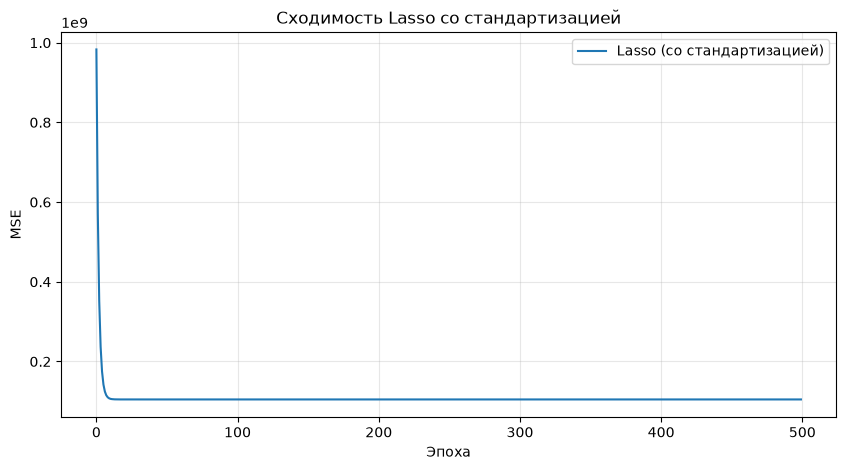

In [19]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(lasso.loss_hist, label='Lasso (со стандартизацией)')
plt.xlabel('Эпоха')
plt.ylabel('MSE')
plt.title('Сходимость Lasso со стандартизацией')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [20]:
def cross_validation(X, y, model, k, lambdas):
    n = len(y)
    indices = np.random.permutation(n)
    X = X[indices]
    y = y[indices]
    
    fold_size = n // k
    results = {}
    
    for lam in lambdas:
        fold_scores = []
        for fold in range(k):
            # Индексы для валидации
            val_start = fold * fold_size
            val_end = val_start + fold_size
            val_indices = list(range(val_start, val_end))
            train_indices = list(range(0, val_start)) + list(range(val_end, n))
            
            # Разделяем данные
            X_train, y_train = X[train_indices], y[train_indices]
            X_val, y_val = X[val_indices], y[val_indices]
            
            # Создаем и обучаем модель
            model_k = model(lambda_=lam)
            model_k.fit(X_train, y_train)
            
            # Валидация
            y_pred = model_k.predict(X_val)
            mse = np.mean((y_pred - y_val) ** 2)
            fold_scores.append(mse)
        
        results[lam] = np.mean(fold_scores)
    
    # Находим лучший λ
    best_lambda = min(results, key=results.get)
    return best_lambda, results

In [21]:
X

array([[4.12214874e+01, 1.48687491e+05, 3.00000000e+00],
       [7.69442870e+01, 1.21136382e+05, 2.00000000e+00],
       [6.33836244e+01, 8.26196948e+04, 4.00000000e+00],
       ...,
       [2.28195475e+01, 5.32591673e+04, 0.00000000e+00],
       [7.84124781e+01, 1.91540350e+05, 4.00000000e+00],
       [7.91450662e+01, 1.05820981e+05, 3.00000000e+00]], shape=(500, 3))

In [ ]:
def make_poly_features(X, degree):
    return np.column_stack([X**d for d in range(1,degree + 1)])
    

array([[4.12214874e+001, 1.48687491e+005, 3.00000000e+000, ...,
                    inf,             inf, 1.21200973e+238],
       [7.69442870e+001, 1.21136382e+005, 2.00000000e+000, ...,
                    inf,             inf, 1.63669530e+150],
       [6.33836244e+001, 8.26196948e+004, 4.00000000e+000, ...,
                    inf,             inf, 2.67877152e+300],
       ...,
       [2.28195475e+001, 5.32591673e+004, 0.00000000e+000, ...,
                    inf,             inf, 0.00000000e+000],
       [7.84124781e+001, 1.91540350e+005, 4.00000000e+000, ...,
                    inf,             inf, 2.67877152e+300],
       [7.91450662e+001, 1.05820981e+005, 3.00000000e+000, ...,
                    inf,             inf, 1.21200973e+238]],
      shape=(500, 1497))

In [32]:
from sklearn.preprocessing import StandardScaler

class PolynomialRegression:
    def __init__(self,rho=.5,penalty = 'lasso',degree=5,learning_rate = 0.01,lambda_=10):
        self.degree = degree
        self.penalty = penalty
        self.lambda_ = lambda_
        self.rho = rho
        self.scaler = StandardScaler()
        self.model = None

    @staticmethod
    def make_poly_features(X, degree):
        """Создаёт полиномиальные признаки: x, x^2, ..., x^degree"""
        X = np.array(X).reshape(-1, 1)  # гарантируем форму (n, 1)
        return np.column_stack([X ** d for d in range(1, degree + 1)])

    def fit(self,X,y):
        X = self.make_poly_features(X,self.degree)
        X = self.scaler.fit_transform(X)

        if self.penalty == 'lasso':
            from sklearn.linear_model import Lasso
            self.model = Lasso(alpha=self.lambda_, fit_intercept=True)
        elif self.penalty == 'ridge':
            from sklearn.linear_model import Ridge
            self.model = Ridge(alpha=self.lambda_, fit_intercept=True)
        elif self.penalty == 'elasticnet':
            from sklearn.linear_model import ElasticNet
            self.model = ElasticNet(alpha=self.lambda_,l1_ratio=self.rho, fit_intercept=True)
        else:
            from sklearn.linear_model import LinearRegression
            self.model = LinearRegression(fit_intercept=True)

        self.model.fit(X,y)

    def predict(self,X):
        X = self.make_poly_features(X,self.degree)
        X = self.scaler.transform(X)
        return self.model.predict(X)

R² на обучении: 0.9630


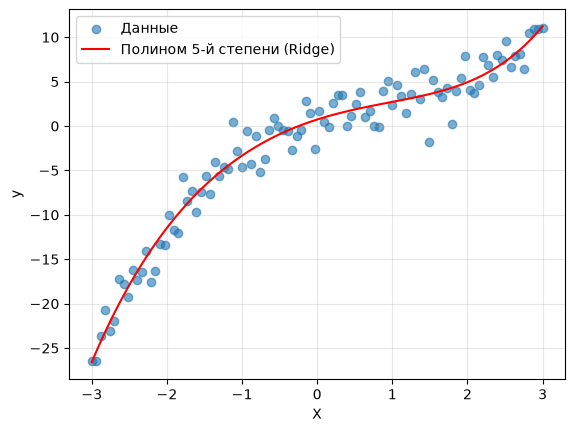

In [33]:
import matplotlib.pyplot as plt

np.random.seed(42)
X = np.linspace(-3, 3, 100).reshape(-1, 1)
y = 0.5 * X.flatten()**3 - X.flatten()**2 + 2 * X.flatten() + 1 + np.random.normal(0, 2, 100)

# Обучаем модель
model = PolynomialRegression(degree=5, penalty='ridge', lambda_=1.0)
model.fit(X, y)
y_pred = model.predict(X)

print(f"R² на обучении: {model.model.score(model.scaler.transform(model.make_poly_features(X, model.degree)), y):.4f}")

# График
plt.scatter(X, y, alpha=0.6, label='Данные')
plt.plot(X, y_pred, color='red', label=f'Полином {model.degree}-й степени (Ridge)')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [34]:
import numpy as np

def sigmoid(z):
    """
    Сигмоида: сжимает любое число в интервал (0, 1).
    """
    return 1 / (1 + np.exp(-z))

In [35]:
def log_loss(y_true, y_pred):
    """
    y_true — истинные метки (0 или 1)
    y_pred — предсказанные вероятности (от 0 до 1)
    """
    # Защита от log(0) — добавляем tiny epsilon
    eps = 1e-15
    y_pred = np.clip(y_pred, eps, 1 - eps)
    
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

In [36]:
y_true = np.array([1, 1, 0])
y_pred = np.array([0.9, 0.6, 0.8])

loss = log_loss(y_true, y_pred)
print(f"Log Loss: {loss:.4f}")

# Посчитаем вклад каждого объекта
for i in range(3):
    eps = 1e-15
    p = np.clip(y_pred[i], eps, 1 - eps)
    contrib = - (y_true[i] * np.log(p) + (1 - y_true[i]) * np.log(1 - p))
    print(f"Объект {i+1}: вклад = {contrib:.4f}")

Log Loss: 0.7419
Объект 1: вклад = 0.1054
Объект 2: вклад = 0.5108
Объект 3: вклад = 1.6094


In [51]:
class LogisticRegressionGD:
    def __init__(self,learning_rate = 0.01,n_epochs = 50,batch_size = 32,penalty = 'lasso',lambda_ = 10,rho = 0.5):
        self.learning_rate = learning_rate
        self.n_epochs = n_epochs
        self.batch_size = batch_size
        self.penalty = penalty
        self.lambda_ = lambda_
        self.rho = rho
        self.scaler = StandardScaler()
        self.model = None
        self.loss_hist = []
        self.w = None
    
    @staticmethod
    def sigmoid(z):
        """
        Сигмоида: сжимает любое число в интервал (0, 1).
        """
        return 1 / (1 + np.exp(-z))

    @staticmethod
    def log_loss(y_true, y_pred):
        """
        y_true — истинные метки (0 или 1)
        y_pred — предсказанные вероятности (от 0 до 1)
        """
        # Защита от log(0) — добавляем tiny epsilon
        eps = 1e-15
        y_pred = np.clip(y_pred, eps, 1 - eps)
        
        return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

    def fit(self,X,y):
        # Стандартизация (без intercept)
        X = self.scaler.fit_transform(X)
        X = np.c_[np.ones((X.shape[0], 1)), X]
        
        self.w = np.random.randn(X.shape[1])
        n=len(y)
        
        for _ in range(self.n_epochs):
            indices = np.random.permutation(n)
            X_shuffled = X[indices]
            y_shuffled = y[indices]

            for i in range(0,n,self.batch_size):
                X_batch = X_shuffled[i:i+self.batch_size]
                y_batch = y_shuffled[i:i+self.batch_size]
                p = self.sigmoid(X_batch@self.w)

                # Градиент регуляризации
                grad_penalty = np.zeros_like(self.w)
                # не штрафуем свободный член, только веса
                if self.penalty == 'lasso':
                    grad_penalty[1:] = self.lambda_* np.where(self.w[1:] > 0, 1, np.where(self.w[1:] < 0, -1, 0)) # субградиент
                elif self.penalty == 'ridge':
                    grad_penalty[1:] = 2 * self.lambda_ * self.w[1:]
                elif self.penalty == 'elasticnet':
                    grad_penalty[1:] = self.lambda_ * self.rho * np.where(self.w[1:] > 0, 1, np.where(self.w[1:] < 0, -1, 0)) + \
                        2 * self.lambda_*(1-self.rho)*self.w[1:]
                
                grad = (1/self.batch_size)*X_batch.T@(p-y_batch) + grad_penalty
                self.w -= self.learning_rate * grad
            self.loss_hist.append(self.log_loss(y_shuffled, self.sigmoid(X_shuffled @ self.w)))

    def predict_proba(self,X):
        X = self.scaler.transform(X)
        X = np.c_[np.ones((X.shape[0], 1)), X]
        
        return  self.sigmoid(X@self.w)
    
    def predict(self,X):
        return  (self.predict_proba(X) >= 0.5).astype(int)
    
    def score(self, X, y):
        """
        Возвращает accuracy на данных.
        """
        y_pred = self.predict(X)
        return np.mean(y_pred == y)


In [ ]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Генерируем данные
X, y = make_classification(n_samples=500, n_features=2, n_redundant=0, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Обучаем модель
model = LogisticRegressionGD(penalty='lasso', lambda_=0.1, n_epochs=200)
model.fit(X_train, y_train)

# Оценка
y_pred = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

Accuracy: 0.8800


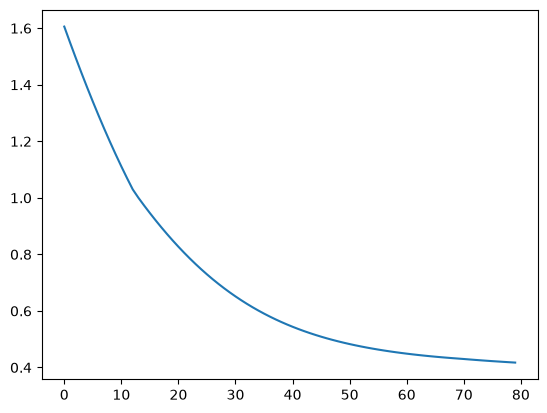

In [47]:
plt.plot(model.loss_hist)

In [50]:
lambdas = [0.01,0.1,1,10,20,50,100]
for lam in lambdas:
    # Обучаем модель
    model = LogisticRegressionGD(penalty='lasso', lambda_=lam, n_epochs=200)
    model.fit(X_train, y_train)

    # Оценка
    y_pred = model.predict(X_test)
    print(f"lambda, Accuracy: {lam},{accuracy_score(y_test, y_pred):.4f}\n")

lambda, Accuracy: 0.01,0.8900

lambda, Accuracy: 0.1,0.8800

lambda, Accuracy: 1,0.3500

lambda, Accuracy: 10,0.6200

lambda, Accuracy: 20,0.1600

lambda, Accuracy: 50,0.3400

lambda, Accuracy: 100,0.4000



In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'learning_rate': [0.01, 0.001, 0.0001],
    'n_epochs': [100, 200, 500],
    'batch_size': [16, 32, 64],
    'penalty': ['lasso', 'ridge', 'elasticnet'],
    'lambda_': [0.01, 0.1, 1, 10],
    'rho': [0.3, 0.5, 0.7]  # только для elasticnet
}



In [55]:
from sklearn.model_selection import GridSearchCV
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Генерируем данные
X, y = make_classification(n_samples=500, n_features=2, n_redundant=0, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Создаём модель
model = LogisticRegression()

# Сетка параметров
param_grid = {
    'penalty': ['lasso', 'ridge'],
    'C': [0.01, 0.1, 1, 10],
    'learning_rate': [0.01, 0.001],
}

# GridSearchCV
grid = GridSearchCV(
    model,
    param_grid,
    cv=3,               # 3 фолда для скорости
    scoring='accuracy',
    n_jobs=-1           # использовать все ядра
)

grid.fit(X_train, y_train)

print(f"Лучшие параметры: {grid.best_params_}")
print(f"Лучшая CV accuracy: {grid.best_score_:.4f}")
print(f"Тестовая accuracy: {grid.score(X_test, y_test):.4f}")

ValueError: Invalid parameter 'learning_rate' for estimator LogisticRegression(C=0.01). Valid parameters are: ['C', 'class_weight', 'dual', 'fit_intercept', 'intercept_scaling', 'l1_ratio', 'max_iter', 'n_jobs', 'penalty', 'random_state', 'solver', 'tol', 'verbose', 'warm_start'].

## SVM

In [57]:
from sklearn.svm import SVC

model = SVC(
    kernel='rbf',        # 'linear', 'poly', 'rbf', 'sigmoid'
    C=1.0,               # штраф за ошибки (чем больше, тем жестче)
    gamma='scale',       # параметр для rbf/poly/sigmoid
    degree=3,            # для полиномиального ядра
    coef0=0.0,           # для полиномиального и sigmoid
    probability=True     # даёт вероятности (через Platt scaling)
)

In [58]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Генерируем данные
X, y = make_classification(n_samples=300, n_features=2, n_redundant=0,
                           n_clusters_per_class=1, random_state=42)

# Разделяем
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



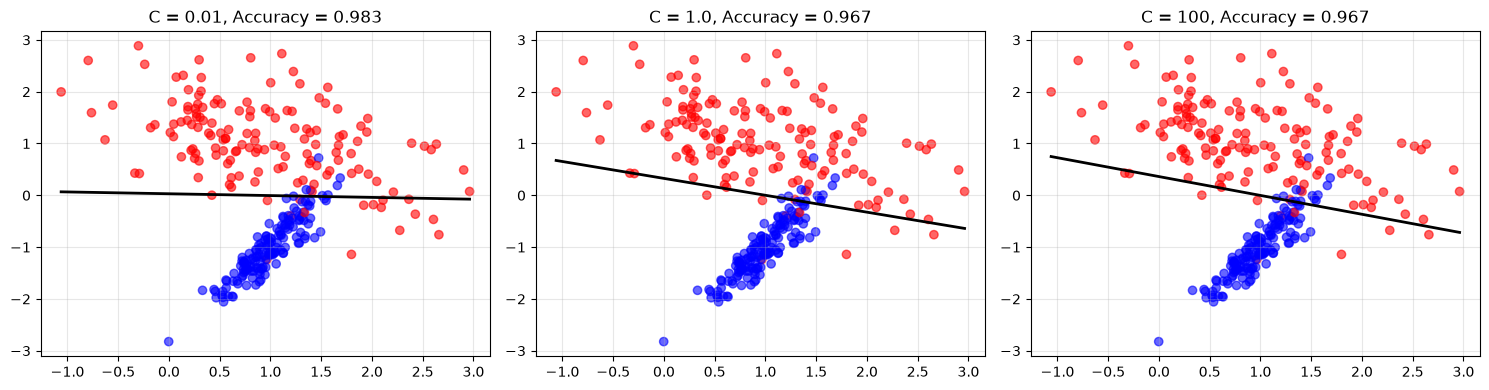

In [59]:
# Обучаем SVM с разными C
C_values = [0.01, 1.0, 100]

plt.figure(figsize=(15, 4))
for i, C in enumerate(C_values):
    model = SVC(kernel='linear', C=C)
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    
    plt.subplot(1, 3, i+1)
    # Рисуем точки
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', alpha=0.6)
    
    # Рисуем разделяющую линию
    w = model.coef_[0]
    b = model.intercept_[0]
    x_plot = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
    y_plot = -(w[0] * x_plot + b) / w[1]
    plt.plot(x_plot, y_plot, 'k-', linewidth=2)
    
    plt.title(f'C = {C}, Accuracy = {acc:.3f}')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

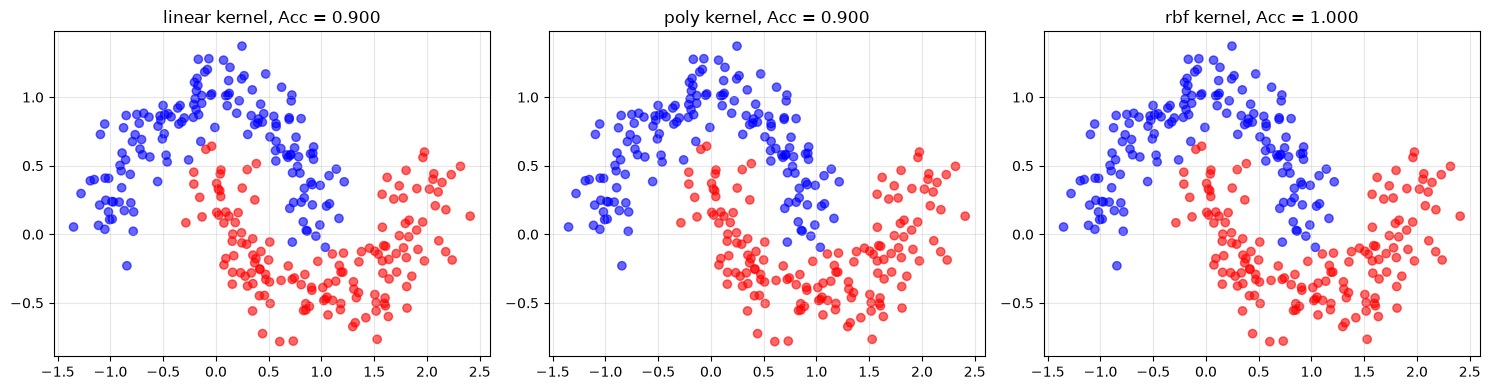

In [62]:
from sklearn.datasets import make_moons

# Генерируем нелинейные данные
X, y = make_moons(n_samples=300, noise=0.15, random_state=42)

# Разделяем
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Сравниваем ядра
kernels = ['linear', 'poly', 'rbf']
plt.figure(figsize=(15, 4))

for i, kernel in enumerate(kernels):
    model = SVC(kernel=kernel, C=1.0, gamma='scale')
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    
    plt.subplot(1, 3, i+1)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', alpha=0.6)
    plt.title(f'{kernel} kernel, Acc = {acc:.3f}')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

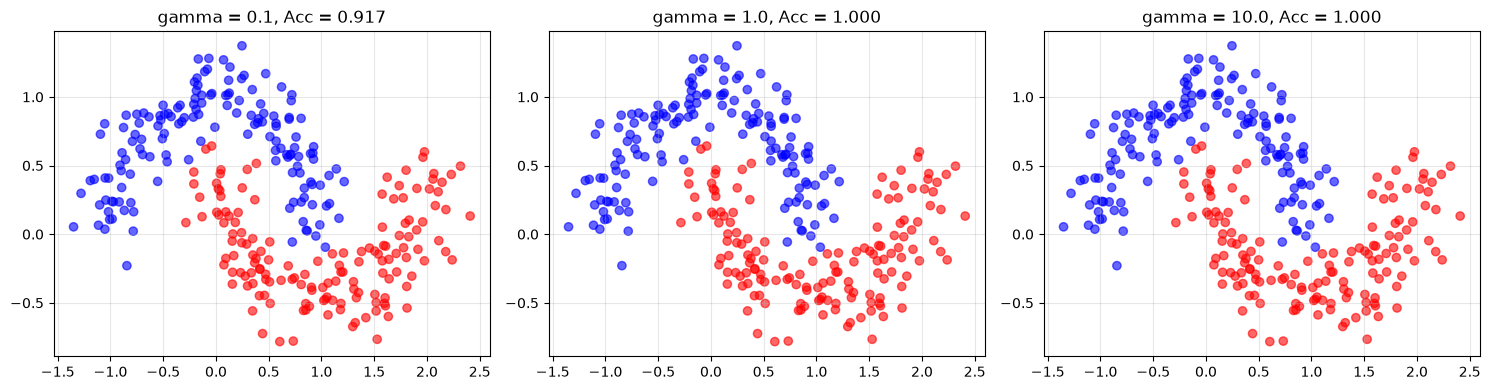

In [63]:
gamma_values = [0.1, 1.0, 10.0]
plt.figure(figsize=(15, 4))

for i, gamma in enumerate(gamma_values):
    model = SVC(kernel='rbf', C=1.0, gamma=gamma)
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    
    plt.subplot(1, 3, i+1)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', alpha=0.6)
    plt.title(f'gamma = {gamma}, Acc = {acc:.3f}')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

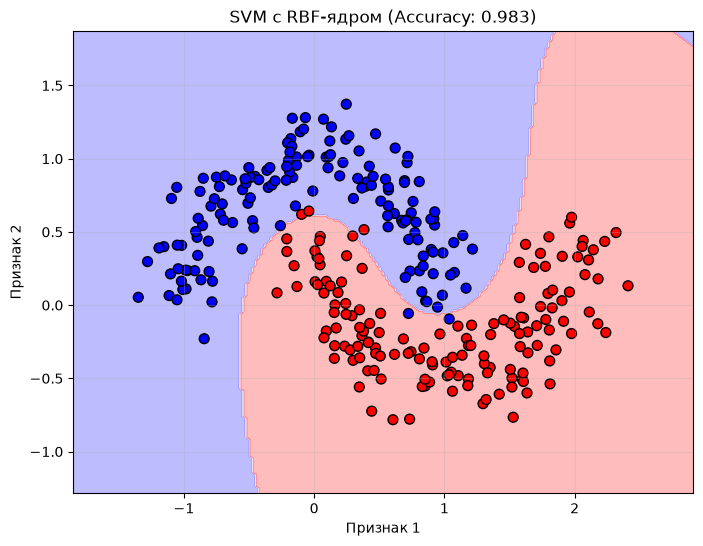

In [64]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Генерируем нелинейные данные
X, y = make_moons(n_samples=300, noise=0.15, random_state=42)

# Обучаем модель
model = SVC(kernel='rbf', C=1.0, gamma=1.0)
model.fit(X, y)

# Создаём сетку для визуализации границы
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

# Предсказываем класс для каждой точки сетки
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Рисуем
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='bwr')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolor='k', s=50)
plt.title(f'SVM с RBF-ядром (Accuracy: {accuracy_score(y, model.predict(X)):.3f})')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.grid(True, alpha=0.3)
plt.show()

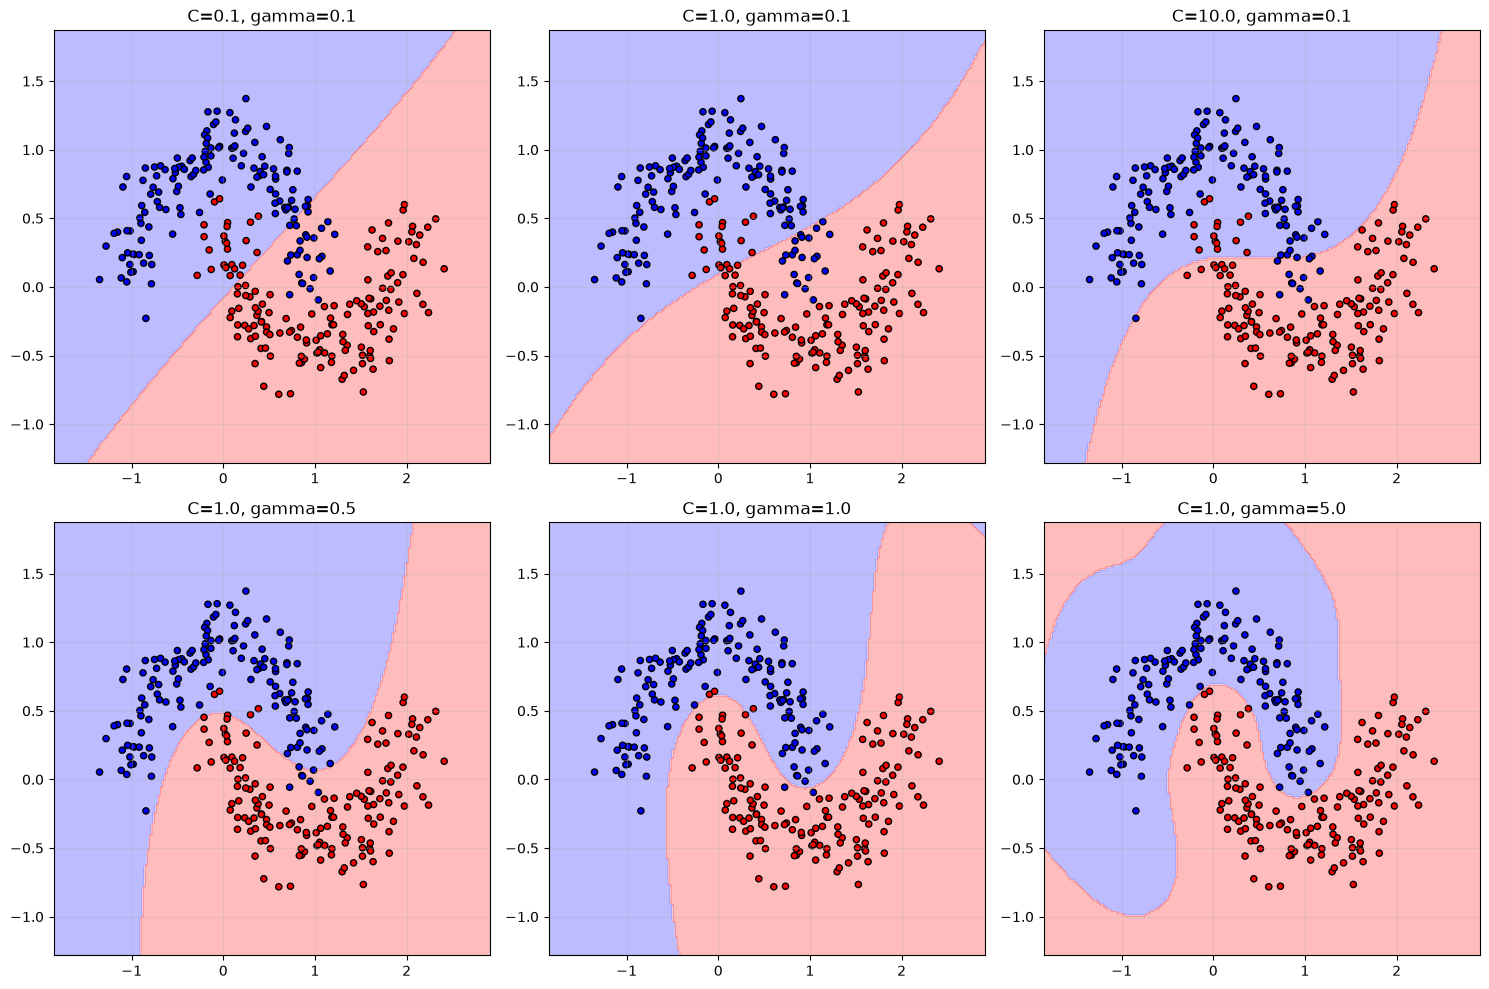

In [65]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

params = [
    {'C': 0.1, 'gamma': 0.1},
    {'C': 1.0, 'gamma': 0.1},
    {'C': 10.0, 'gamma': 0.1},
    {'C': 1.0, 'gamma': 0.5},
    {'C': 1.0, 'gamma': 1.0},
    {'C': 1.0, 'gamma': 5.0}
]

for ax, param in zip(axes.ravel(), params):
    model = SVC(kernel='rbf', C=param['C'], gamma=param['gamma'])
    model.fit(X, y)
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='bwr')
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolor='k', s=20)
    ax.set_title(f'C={param["C"]}, gamma={param["gamma"]}')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Лучшие параметры: {'svm__C': 0.1, 'svm__gamma': 10}
Лучшая CV accuracy: 0.9750
Тестовая accuracy: 0.9700


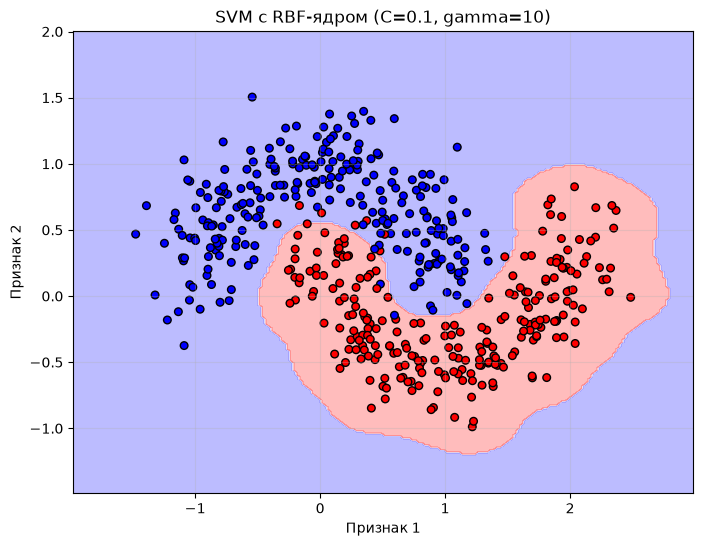

In [66]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix

# ===============================
# 1. ДАННЫЕ
# ===============================
X, y = make_moons(n_samples=500, noise=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ===============================
# 2. ПАЙПЛАЙН (SCALER + SVM)
# ===============================
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', probability=True, random_state=42))
])

# ===============================
# 3. GRIDSEARCHCV
# ===============================
param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': [0.01, 0.1, 1, 10]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid.fit(X_train, y_train)

# ===============================
# 4. РЕЗУЛЬТАТЫ
# ===============================
print(f"Лучшие параметры: {grid.best_params_}")
print(f"Лучшая CV accuracy: {grid.best_score_:.4f}")
print(f"Тестовая accuracy: {grid.score(X_test, y_test):.4f}")

# ===============================
# 5. ВИЗУАЛИЗАЦИЯ ГРАНИЦЫ (С ЛУЧШИМИ ПАРАМЕТРАМИ)
# ===============================
best_model = grid.best_estimator_
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

# Получаем предсказания (через pipeline)
Z = best_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='bwr')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolor='k', s=30)
plt.title(f'SVM с RBF-ядром (C={grid.best_params_["svm__C"]}, gamma={grid.best_params_["svm__gamma"]})')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.grid(True, alpha=0.3)
plt.show()

In [67]:
param_grid = [
    {
        'svm__kernel': ['rbf'],
        'svm__C': [0.1, 1, 10, 100],
        'svm__gamma': [0.01, 0.1, 1, 10]
    },
    {
        'svm__kernel': ['poly'],
        'svm__C': [0.1, 1, 10],
        'svm__degree': [2, 3, 4],
        'svm__coef0': [0, 1]
    }
]

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid.fit(X_train, y_train)

print(f"Лучшие параметры: {grid.best_params_}")
print(f"Лучшая CV accuracy: {grid.best_score_:.4f}")
print(f"Тестовая accuracy: {grid.score(X_test, y_test):.4f}")

Лучшие параметры: {'svm__C': 0.1, 'svm__gamma': 10, 'svm__kernel': 'rbf'}
Лучшая CV accuracy: 0.9750
Тестовая accuracy: 0.9700


In [1]:
import numpy as np
from collections import Counter
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


In [4]:
class KNN:
    def __init__(self,k=5,metric = 'euclidean'):
        self.k = k
        self.metric = metric
        self.X_train = None
        self.y_train = None
    
    def fit(self,X,y):
        # KNN ленивый — просто запоминаем данные
        self.X_train = X
        self.y_train = y

    def _distance(self,x1,x2):
        if self.metric == 'euclidean':
            return np.sqrt(np.sum(x1-x2)**2)
        elif self.metric == 'manhattan':
            return np.sum(np.abs(x1 - x2))
        else:
            raise ValueError(f"Unknown metric: {self.metric}")
        
    def predict(self, X):
        predictions = []

        for x in X:
            distances = [self._distance(x,x_train) for x_train in self.X_train]
            k_indices = np.argsort(distances)[:self.k]
            k_labels = self.y_train[k_indices]
            most_common = Counter(k_labels).most_common(1)[0][0]
            predictions.append(most_common)
        return np.array(predictions)
    
    def score(self,X,y):
        return accuracy_score(y, self.predict(X))

In [5]:
# Генерируем синтетические данные
X, y = make_classification(n_samples=300, n_features=2, n_redundant=0, n_clusters_per_class=1, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Обучаем KNN
knn = KNN(k=5)
knn.fit(X_train, y_train)

# Оценка
acc = knn.score(X_test, y_test)
print(f"KNN (k=5) Accuracy: {acc:.4f}")

KNN (k=5) Accuracy: 0.8333


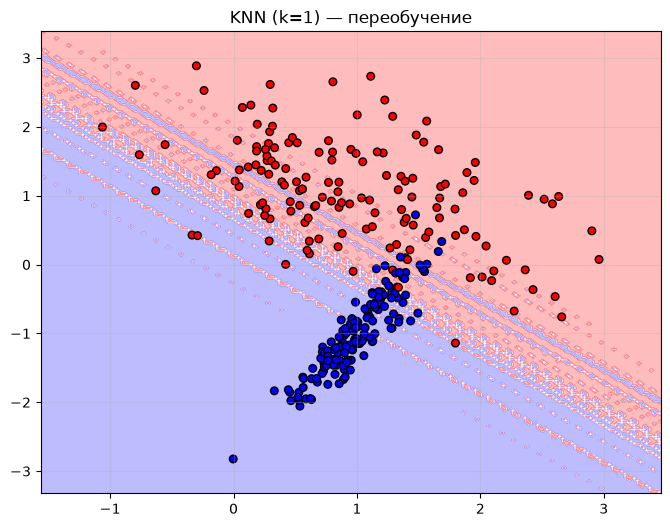

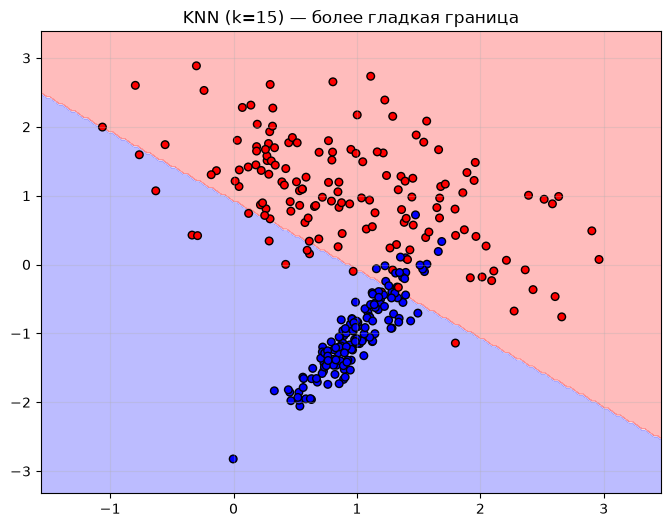

In [6]:
import matplotlib.pyplot as plt

def plot_knn_boundary(X, y, knn_model, title="KNN Decision Boundary"):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))

    Z = knn_model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='bwr')
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolor='k', s=30)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.show()

# Сравнение K = 1 и K = 15
knn1 = KNN(k=1)
knn1.fit(X_train, y_train)
plot_knn_boundary(X, y, knn1, title="KNN (k=1) — переобучение")

knn15 = KNN(k=15)
knn15.fit(X_train, y_train)
plot_knn_boundary(X, y, knn15, title="KNN (k=15) — более гладкая граница")

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(
    n_neighbors=5,
    algorithm='kd_tree',  # или 'ball_tree', 'brute' (полный перебор)
    leaf_size=30          # размер листа для дерева
)

In [7]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Генерируем данные
X, y = make_classification(n_samples=500, n_features=2, n_redundant=0, n_clusters_per_class=1, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Пайплайн
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

# Сетка параметров
param_grid = {
    'knn__n_neighbors': [1, 3, 5, 7, 9, 11, 15, 20],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan']
}

# GridSearchCV
grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)

print(f"Лучшие параметры: {grid.best_params_}")
print(f"Лучшая CV accuracy: {grid.best_score_:.4f}")
print(f"Тестовая accuracy: {grid.score(X_test, y_test):.4f}")

Лучшие параметры: {'knn__metric': 'euclidean', 'knn__n_neighbors': 3, 'knn__weights': 'distance'}
Лучшая CV accuracy: 0.9625
Тестовая accuracy: 0.9500


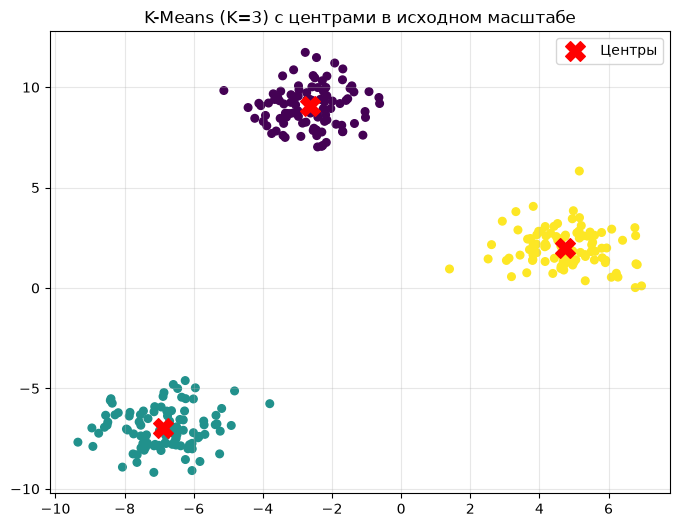

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Генерируем данные
X, y_true = make_blobs(n_samples=300, centers=3, cluster_std=1.0, random_state=42)

# Стандартизация
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Обучаем K-Means на стандартизированных данных
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
y_pred = kmeans.fit_predict(X_scaled)

# Переводим центры обратно в исходный масштаб
centers_original = scaler.inverse_transform(kmeans.cluster_centers_)

plt.figure(figsize=(8, 6))
# Рисуем данные
plt.scatter(X[:, 0], X[:, 1], c=y_pred, cmap='viridis', s=30)
plt.scatter(centers_original[:, 0], centers_original[:, 1],
            c='red', marker='X', s=200, label='Центры')
plt.title('K-Means (K=3) с центрами в исходном масштабе')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

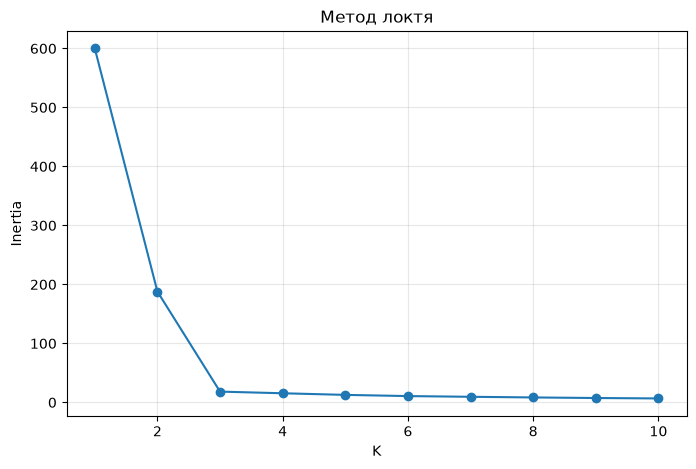

In [10]:
inertias = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, marker='o')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.title('Метод локтя')
plt.grid(True, alpha=0.3)
plt.show()

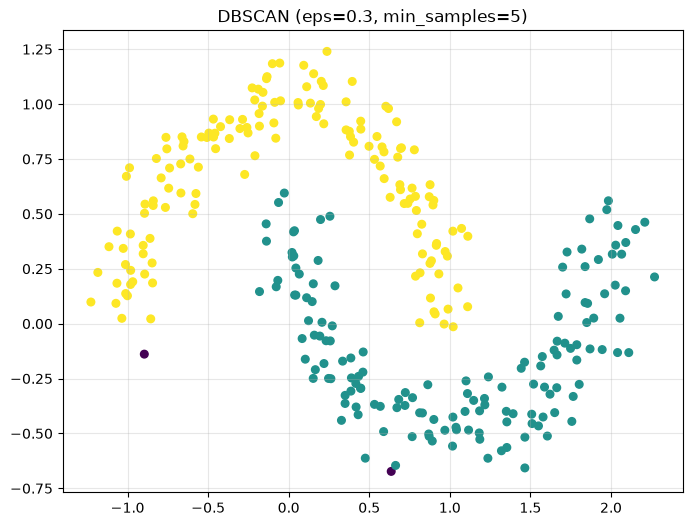

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# Генерируем данные в форме двух полумесяцев (non-linear)
X, _ = make_moons(n_samples=300, noise=0.1, random_state=42)

# Стандартизация (важна для DBSCAN, т.к. eps зависит от масштаба)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Обучаем DBSCAN
dbscan = DBSCAN(eps=0.3, min_samples=5)
y_pred = dbscan.fit_predict(X_scaled)

# Визуализация
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y_pred, cmap='viridis', s=30)
plt.title(f'DBSCAN (eps=0.3, min_samples=5)')
plt.grid(True, alpha=0.3)
plt.show()



In [14]:
# Сколько кластеров и шума?
unique_labels = set(y_pred)
n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
n_noise = list(y_pred).count(-1)
print(f"Число кластеров: {n_clusters}")
print(f"Число шумовых точек: {n_noise}")

Число кластеров: 2
Число шумовых точек: 2


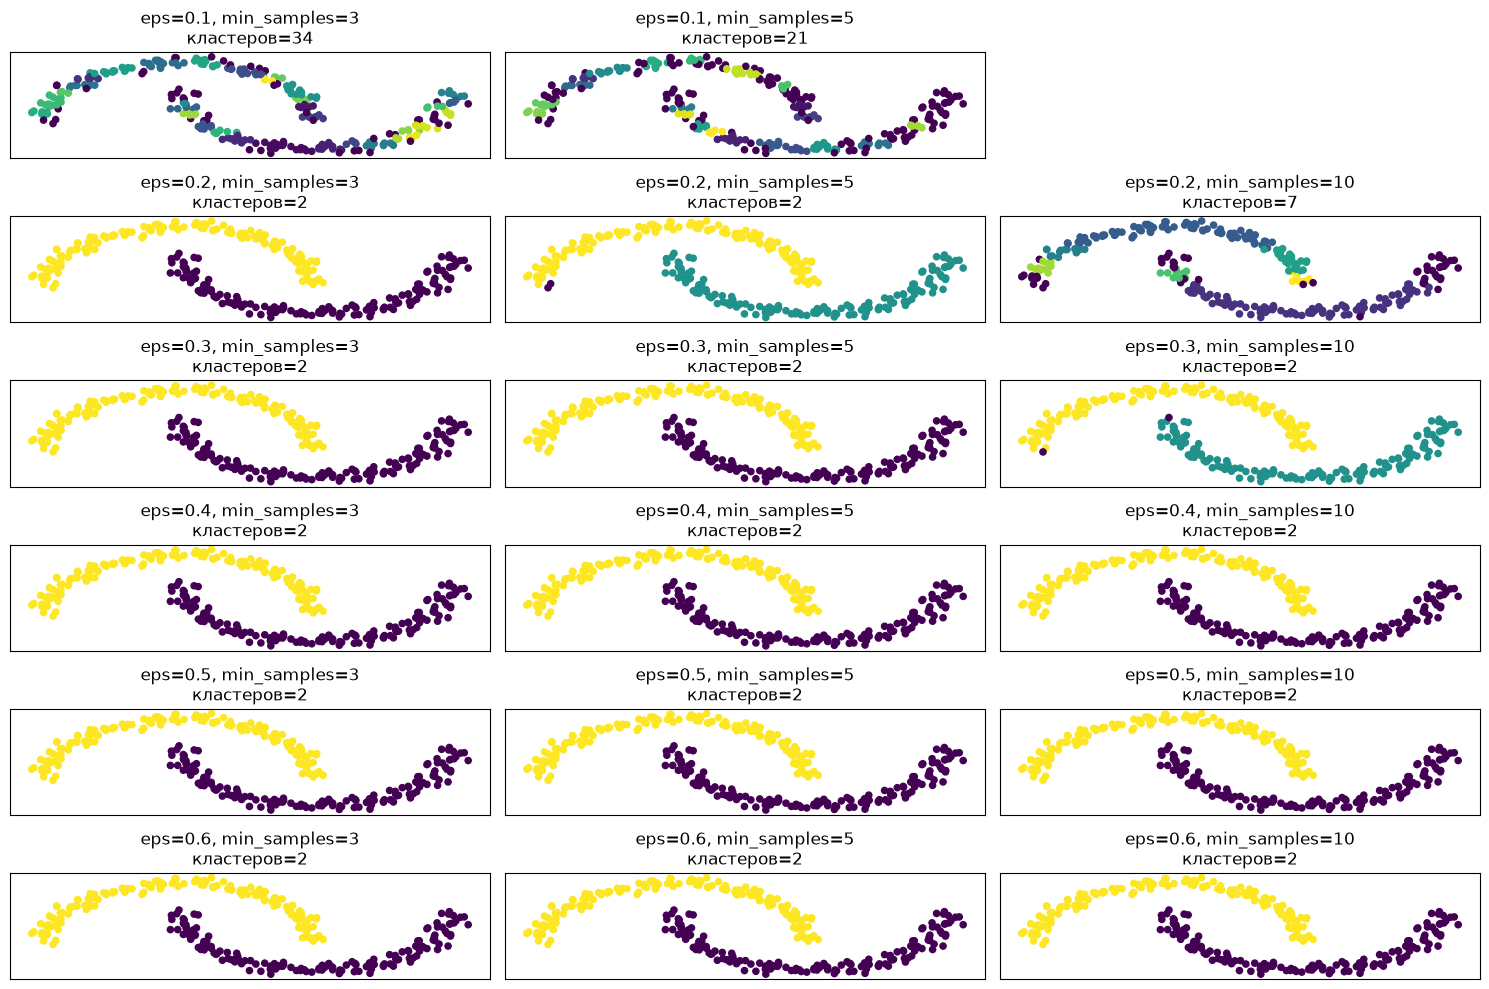

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

X, _ = make_moons(n_samples=300, noise=0.05, random_state=42)
X_scaled = StandardScaler().fit_transform(X)

# Перебираем eps и min_samples
eps_values = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6]
min_samples_values = [3, 5, 10]

plt.figure(figsize=(15, 10))

for i, eps in enumerate(eps_values):
    for j, min_s in enumerate(min_samples_values):
        dbscan = DBSCAN(eps=eps, min_samples=min_s)
        labels = dbscan.fit_predict(X_scaled)
        
        # Пропускаем, если только шум или 1 кластер
        if len(set(labels)) <= 1:
            continue
        
        plt.subplot(len(eps_values), len(min_samples_values), i * len(min_samples_values) + j + 1)
        plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=20)
        plt.title(f'eps={eps}, min_samples={min_s}\nкластеров={len(set(labels)) - (1 if -1 in labels else 0)}')
        plt.xticks([])
        plt.yticks([])

plt.tight_layout()
plt.show()

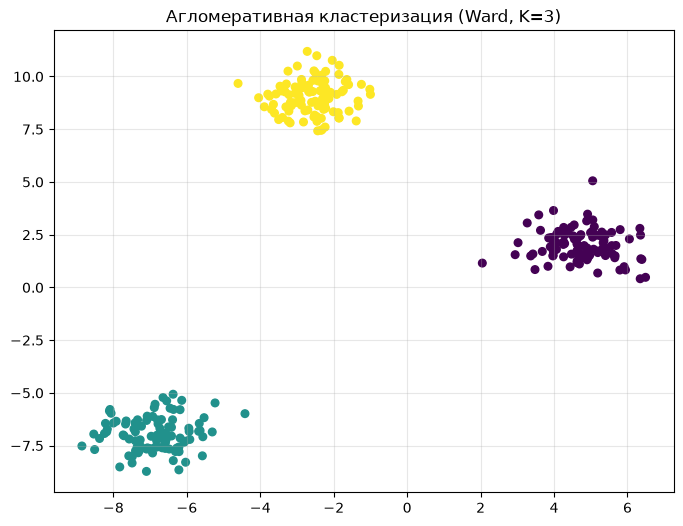

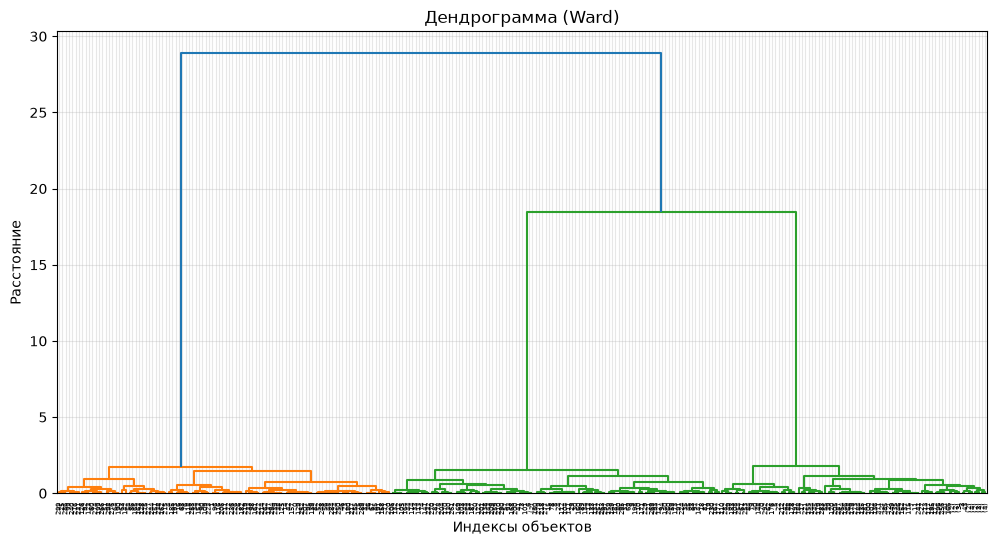

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler

# Генерируем данные
X, _ = make_blobs(n_samples=300, centers=3, cluster_std=0.8, random_state=42)

# Стандартизация
X_scaled = StandardScaler().fit_transform(X)

# Ward — стандарт для агломеративной кластеризации
model = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
y_pred = model.fit_predict(X_scaled)

# Визуализация
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y_pred, cmap='viridis', s=30)
plt.title('Агломеративная кластеризация (Ward, K=3)')
plt.grid(True, alpha=0.3)
plt.show()

# ==========================================
# 2. ДЕНДРОГРАММА
# ==========================================
# Строим матрицу связей для дендрограммы
linkage_matrix = linkage(X_scaled, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix, truncate_mode='level', p=10)
plt.title('Дендрограмма (Ward)')
plt.xlabel('Индексы объектов')
plt.ylabel('Расстояние')
plt.grid(True, alpha=0.3)
plt.show()

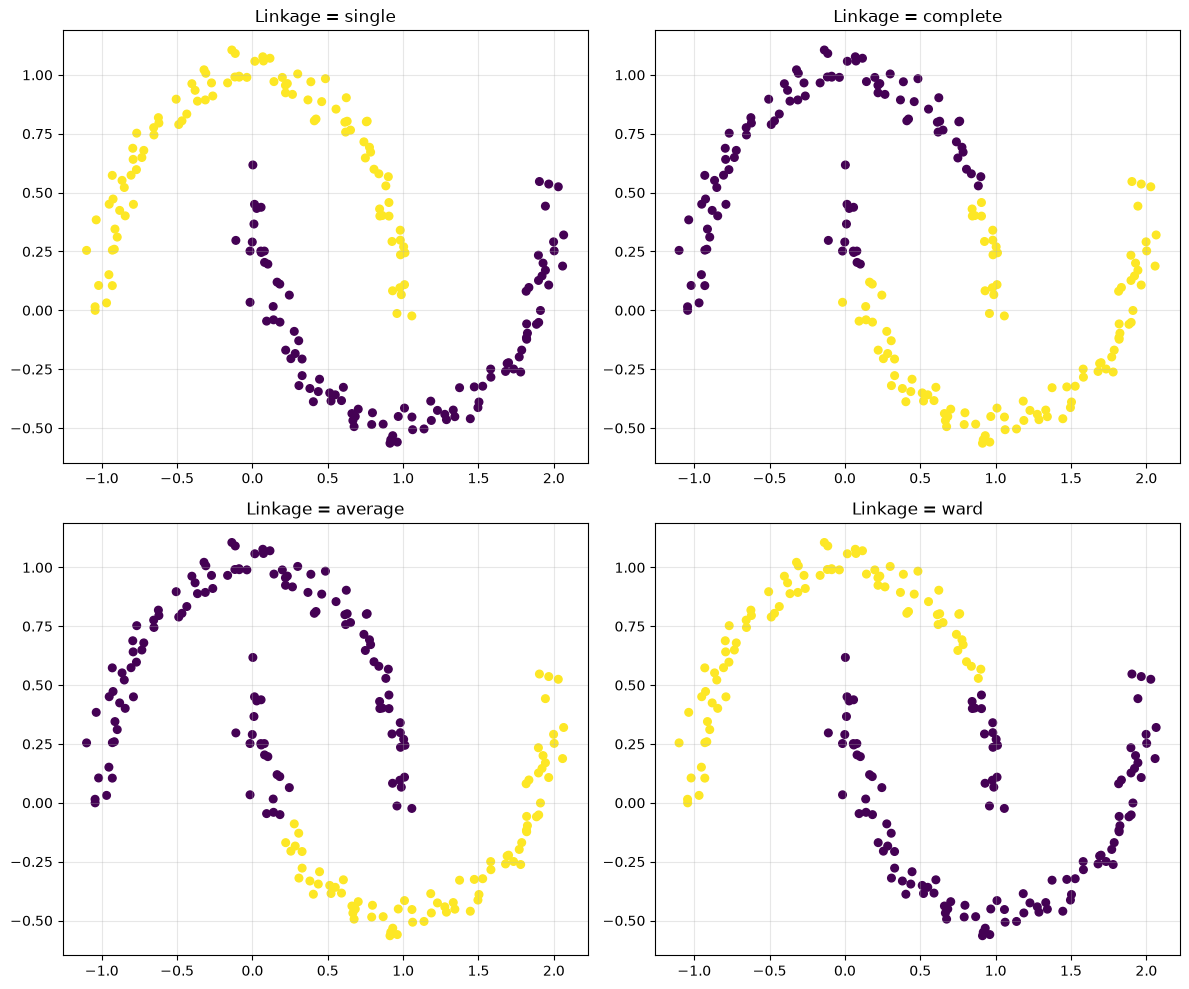

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_moons
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler

# Данные: два полумесяца (нелинейные)
X, _ = make_moons(n_samples=200, noise=0.05, random_state=42)
X_scaled = StandardScaler().fit_transform(X)

# Сравниваем методы
methods = ['single', 'complete', 'average', 'ward']
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, method in zip(axes.ravel(), methods):
    model = AgglomerativeClustering(n_clusters=2, metric='euclidean', linkage=method)
    y_pred = model.fit_predict(X_scaled)
    
    ax.scatter(X[:, 0], X[:, 1], c=y_pred, cmap='viridis', s=30)
    ax.set_title(f'Linkage = {method}')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()